¡Hola Jose! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.
</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.
</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Jose!

Realizaste un trabajo sólido en la estructura general del proyecto: cargaste los tres datasets, exploraste su contenido, limpiaste varios problemas importantes, construiste métricas por usuario, generaste visualizaciones comparativas por plan, creaste segmentaciones y redactaste un análisis ejecutivo con recomendaciones para ConnectaTel. También compartiste un repositorio de GitHub con README y notebook, lo cual cumple con el entregable de publicación.

Antes de aprobar el proyecto, necesitamos corregir algunos puntos bloqueantes:

- En la identificación de problemas de calidad, falta implementar y aplicar una función reutilizable para detectar valores inválidos/sentinels en los tres datasets. Además, el diagnóstico debe reconocer explícitamente `age = -999`, `city = "?"`, las fechas fuera de rango y los nulos estructurales de `duration`/`length`.
- En la conversión de fechas, usa una versión a prueba de errores con `errors='coerce'`, como pide la consigna.
- En el cálculo de límites IQR de la Parte 5, la fórmula no está bien aplicada. Recuerda que el límite superior se calcula como `Q3 + 1.5 * IQR` y el inferior como `Q1 - 1.5 * IQR`. Al corregir esto, revisa nuevamente tu decisión sobre los outliers.

Cuando ajustes estos puntos, tu proyecto quedará mucho más consistente y listo para aprobación.

Saludos,  
Gina Buvoli
</div>


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo en la carga y exploración inicial, Jose. Importaste las librerías necesarias, cargaste correctamente los tres datasets y revisaste tanto las primeras filas como la estructura general con `.shape` e `.info()`. Esta base permite continuar con la revisión de calidad de datos de forma ordenada.

</div>


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
def valores_invalidos(df, columnas):
    filas = []
    for col in columnas:
        cant_999 = (df[col] == -999).sum()
        cant_signo = (df[col].astype(str) == "?").sum()
        cant_nulos = df[col].isna().sum()
        filas.append([col, cant_999, cant_signo, cant_nulos])

    tabla = pd.DataFrame(filas, columns=["columna", "cant_-999", "cant signo_?", "cant_nulos"])
    return tabla

print("Usuarios:")
print(valores_invalidos(users, users.columns))

print("Planes:")
print(valores_invalidos(plans, plans.columns))

print("Uso:")
print(valores_invalidos(usage, usage.columns))

Usuarios:
      columna  cant_-999  cant signo_?  cant_nulos
0     user_id          0             0           0
1  first_name          0             0           0
2   last_name          0             0           0
3         age         55             0           0
4        city          0            96         469
5    reg_date          0             0           0
6        plan          0             0           0
7  churn_date          0             0        3534
Planes:
             columna  cant_-999  cant signo_?  cant_nulos
0          plan_name          0             0           0
1  messages_included          0             0           0
2       gb_per_month          0             0           0
3   minutes_included          0             0           0
4    usd_monthly_pay          0             0           0
5         usd_per_gb          0             0           0
6    usd_per_message          0             0           0
7     usd_per_minute          0             0           0
U

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

<span style="color:blue">En el dataframe **users**, en la columna *city*, tenemos 50 valores nulos, que representa el 11.7% . Dado que se encuentra en el rango de 5% y 30% podriamos imputar con un valor *default*, por ejemplo *Desconocido*. No se considera eliminarlos por que puede afectar al análisis. En este mismo dataframe, la columna *churn_date* tiene 3534 valores nulos, representando el 88.3%. En este caso se recomienda ignorar y no hacer ningun tipo de cambio sobre esta columna, ya que tiene información valiosa de retención para futuros análisis.
</span>
<span style="color:blue">
Para el caso del dataframe **usage** tenemos 50 valores nulos en el campo *date* representando solo el 0.12%. En este caso podriamos dejarlos como estan ya que no representarian impacto en el análisis. Respecto al campo *duration* tenemos 22075 nulos, que representan el 55.1% y para el campo *lenght* tenemos 17896 valores nulos, representando el 44.7%. Estos datos no son valores faltantes reales, si no que dependen del campo *type*. Los registros del tipo *call* tienen valor en el campo *duration* y no en *text*, por el contrario, los registros del tipo *text* tienen valor en el campo *lenght* y no en el campo *duration*.
</span>


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [11]:
# explorar columnas numéricas de users

users[['user_id','age']].describe()
print()

q1 = users['age'].quantile(0.25)
q3 = users['age'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr


# Filtrar outliers
outliers = users[(users['age'] < lower) | (users['age'] > upper)]

outliers_999 = users[users['age']==-999]

print(f"Número de outliers en columna 'age': {len(outliers)}")
print(f"Número de registros con age = -999: {len(outliers_999)}")


Número de outliers en columna 'age': 55
Número de registros con age = -999: 55


- La columna `user_id` <span style="color:blue">no tiene ningun valor nulo y sirve para identificar de manera unica a cada usuario, por lo que no será relevante para el análisis.</span>
- La columna `age` <span style="color:blue"> no tiene ningun valor nulo, sin embargo notamos 55 ouliers. Se evaluara si conviene imputarlos con la mediana. </span>

In [12]:
# explorar columnas numéricas de usage

usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [13]:

# verificando duration
q1_duration = usage['duration'].quantile(0.25)
q3_duration = usage['duration'].quantile(0.75)
iqr_duration = q3_duration - q1_duration
lower_duration = q1_duration - 1.5 * iqr_duration
upper_duration = q3_duration + 1.5 * iqr_duration
# Filtrar outliers
outliers_duration = usage[(usage['duration'] < lower_duration) | (usage['duration'] > upper_duration)]
print(f"Número de outliers en columna 'duration': {len(outliers_duration)}")
#outliers_duration.sort_values('duration', ascending=False)

Número de outliers en columna 'duration': 869


In [14]:
# verificando length
q1_length = usage['length'].quantile(0.25)
q3_length = usage['length'].quantile(0.75)
iqr_length = q3_length - q1_length
lower_length = q1_length - 1.5 * iqr_length
upper_length = q3_length + 1.5 * iqr_length
# Filtrar outliers
outliers_length = usage[(usage['length'] < lower_length) | (usage['length'] > upper_length)]
print(f"Número de outliers en columna 'lenght': {len(outliers_length)}")
#outliers_length.sort_values('length', ascending=False)

Número de outliers en columna 'lenght': 91


- Las columnas `id` y `user_id` <span style="color:blue"> no tienen outliers, lo cual hace sentido ya que se tratan de identificadores secuenciales en los que no se puede aplicar el método IQR</span>
- Las columnas <span style="color:blue">*duration* y *length* son aptas para aplicar IQR. La columna *duration* presenta 869 valores, que bien pueden representar llamadas realmente largas. La columna *length* tiene 91 valores outlier, que pueden representar mensajes de longitud atipica, probablemente sospechosos y que valdria la pena revisar.</span>

In [15]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
columnas_user.describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [16]:
columnas_user['city'].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [17]:
columnas_user['plan'].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city` <span style="color:blue"> tiene 7 valores únicos, sin embargo 2 de estos no son consistentes, existen registros con el simbolo de interrogacion *?* y otros con valor no determinado *nan*. A estos valores valdria la pena indicar un valor *No definido* para tener consistencia en el dataframe. Asi tambien se nota que para las ciudades de Colombia las ciudades vienen descritas completamente mientras que las ciudades de México vienen abreviadas.</span>
- La columna `plan` <span style="color:blue"> en contraste, no presenta ninguna incosistencia. Solo presenta dos valores posibles; *Basico* y *Premium* por lo que no necesita ningún tipo de mantenimiento.</span>

In [18]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [19]:
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` del dataframe **usage** <span style="color:blue">solo tiene 2 valores únicos y posibles, *call* y *text*, por lo tanto tampoco requiere ningún tipo de mantenimiento.</span>


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?
  
<span style="color:blue">La única columna donde se encontraron valores inválidos fue en la columna *city* del dataframe **users**. En esta se encontraron signos de interrogación y valores inválidos (nan). En este caso como se indicó anteriormente, se sugiere inputar estos valores con un valor default como *No definido*. Y para las ciudades correspondientes a México, se recomienda inputar las ciudades sin abreviaciones, por temas de estética en la información</span>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` del data frame **users**, <span style="color:blue">se puede visualizar que hay información de los años **2022**, **2023**, **2024** y **2026**. No existe informacion para el año **2025** y solo hay 40 registros con el año **2026**. Por lo tanto, y para fines prácticos del proyecto solo **se considerarán los registros de los años 2022 al 2024** </span>

In [23]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, <span style="color:blue">se puede observar que solo existe información correspondiente al año 2024, por lo que todos los análisis posteriores se realizaran sobre este año.</span>

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

<span style="color:blue">En el dataframe de **users**, aparecen años del 2022 al 2024, no hay información del 2025 y tiene poca información del 2026. Dado que el dataframe de **usage** solo hay información del 2024. Respecto a las columnas con valores `-999` encontramos 55 valores en el campo `age` del dataframe de usuarios. Estos se podran sustituir por la mediana para no afectar el análisis. En el mismo dataframe usuarios, se encuentran 96 valores con `?` en el campo `city`, estos valores se pueden sustituir por NaN. 
</span>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

En esta parte detectaste varios elementos importantes, pero falta completar un requisito central de la consigna: crear una función reutilizable, por ejemplo `valores_invalidos(df, columnas)`, y aplicarla a los tres datasets para revisar valores como `-999` y `"?"`. Además, el diagnóstico escrito debe ser más preciso: sí debe mencionar `age = -999`, `city = "?"`, los años 2026 en `reg_date` y los nulos de `duration`/`length` según el tipo de evento. También recuerda convertir fechas con una versión a prueba de errores usando `pd.to_datetime(..., errors='coerce')`. No es necesario excluir usuarios de 2022 o 2023; el problema principal son las fechas futuras fuera del rango esperado.
</div>


- Se agrega funcion reutilizable en el paso 10 de ejecución
- Se agrega `errors='coerce'` en las funciones `pd.to_datetime`
- Se complementa el diagnostico indicando las columnas con valores `-999` y con `?`

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age

#se reemplaza -999 por NaN
users['age'] = users['age'].replace(-999, pd.NA)

#se calcula la mediana
age_mediana = users['age'].median()

print(f"Mediana de age: {age_mediana}")

users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

Mediana de age: 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city

#se reemplaza ? por NA
users['city'] = users['city'].replace('?', pd.NA)

print(f"Nulos en city: {users['city'].isna().sum()}")

# Verificar cambios
users['city'].describe()

Nulos en city: 565


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [26]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration_null'] = usage['duration'].isna().astype(int)

usage.groupby('type')['duration_null'].mean()

type
call    0.000000
text    0.999276
Name: duration_null, dtype: float64

In [28]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_null'] = usage['length'].isna().astype(int)
usage.groupby('type')['length_null'].mean()

type
call    0.99933
text    0.00000
Name: length_null, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

<span style="color:blue">
    
Con la ayuda de una columna auxiliar se identificó si el valor de *duration* o *length* eran nulos. Es decir 1 para decir que son nulos y 0 para decir que si tienen valor. Esto ayuda a realizar una agrupacion por el campo *type* para identificar si estos valores son nulos aleatoriamente.

Por lo tanto se puede observar que para el campo *duration* los nulos dependen de que el *type* sea *text*. Lo cual hace sentido, es decir, un mensaje de texto no puede tener duración, pero sí longitud. Por el contrario, para el campo *length* los nulos dependen de que el *type* sea *call*. 

**Conclusión:** ambos campos son MAR.
</span>

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Muy bien aplicada la limpieza principal: reemplazaste el sentinel `-999` en `age`, convertiste `"?"` en `city` a valores nulos y marcaste las fechas futuras como `NaT`. También verificaste correctamente que los nulos de `duration` y `length` dependen del tipo de evento, por lo que tiene sentido mantenerlos como nulos estructurales y no imputarlos.

</div>


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario


usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('is_text','sum'),
    cant_llamadas = ('is_call', 'sum'),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on="user_id", how="left")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.138285
std,1154.898108,2.358416,2.144238,18.168095,17.691541
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,48.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

La agregación por usuario está bien construida y las métricas `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` quedan claras. Como mejora, en el `merge` conviene especificar explícitamente `how='left'` para conservar la base de usuarios completa, tal como solicita el proyecto. También puedes eliminar la celda de “renombrar columnas” si ya definiste los nombres directamente dentro de `.agg()`.
</div>


- Se agrega `how='left'` en el paso 30 de ejecución

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

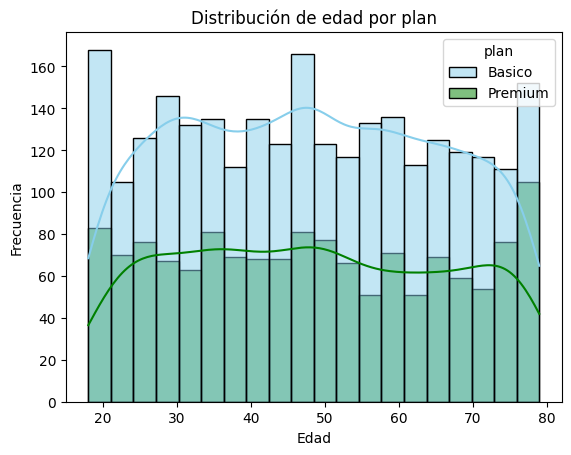

In [33]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', bins=20, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
<span style="color:blue">Ambos planes parecen tener una distribucion uniforme en todas las edades. La edad no parece ser una variable que defina que tipo de plan elije cada usuario</span>

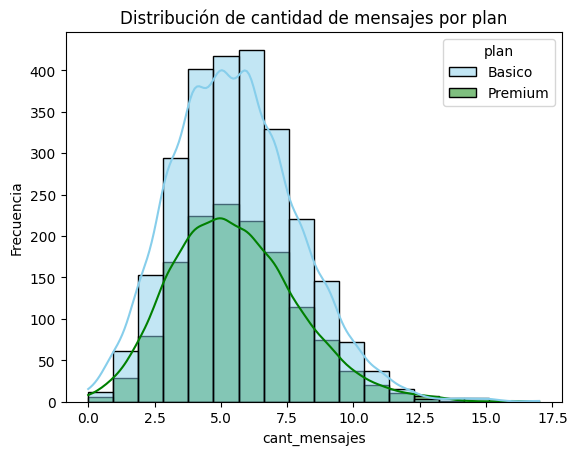

In [34]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', bins=18, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('cant_mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
<span style="color:blue">Se puede visualizar una distribución en forma de campana lo que quiere decir que la mayoria de los usuarios, independientemente del plan mandan entre 4 y 7 mensajes. Puede apreciarse tambien que los usuarios premium, al tener mas minutos incluidos en su plan prefieren hacer llamadas que mandar mensajes.</span>

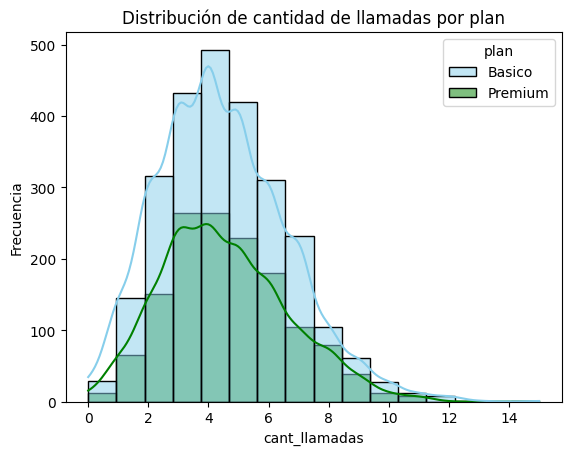

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=16, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('cant_llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
<span style="color:blue"> Se puede observar tambien una distribución en forma de campana en ambos planes, indicando que la mayoria de los usuarios hacen entre 3 y 5 llamadas. Parece que muy pocos usuarios de plan básico hacen mas de 10 llamadas, lo que probablemente indique que son potenciales a convertirse a plan premium 
</span>


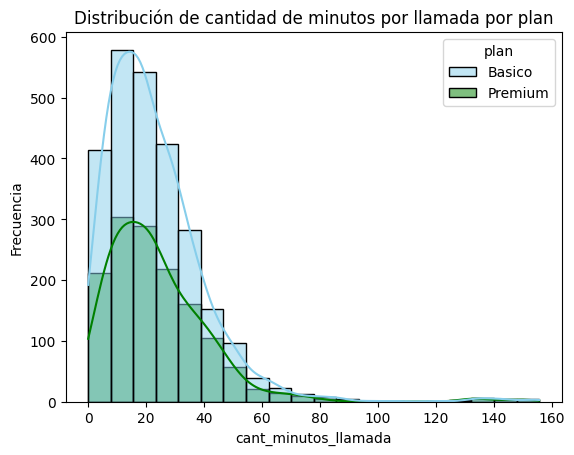

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=20, kde=True, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de minutos por llamada por plan')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
<span style="color:blue">
La distribución esta sesgada fuertemente a la derecha, con la gran mayoría de usuarios concentrados entre 0 y 40 minutos, y una cola larga que se extiende hasta los 160 minutos. El pico de frecuencia está alrededor de los 10-15 minutos, lo que indica que ese es el rango de consumo más común. Se aprecia que los usuarios de plan premium suelen realizar llamadas de mas duración, probablemente al aprovechar los beneficios de este plan. Tambien se aprecia un numero pequeño de usuarios que suelen tener llamadas de 130 a 150 minutos. En contraste se puede visualizar un segmento importante de usuarios con plan básico con consumo muy bajo, lo que puede representar riesgo de abandono.
</span>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `cant_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

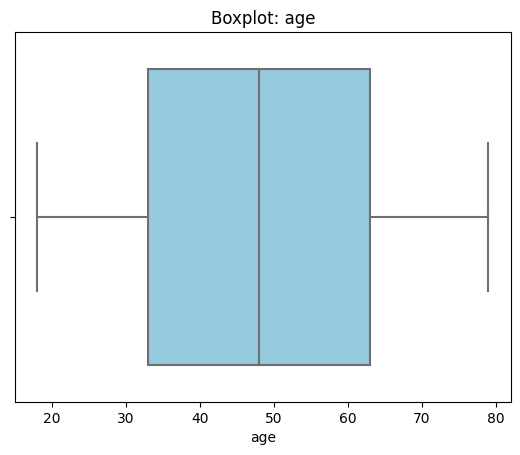

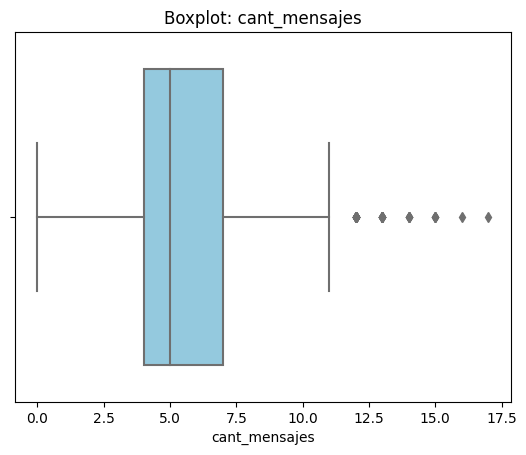

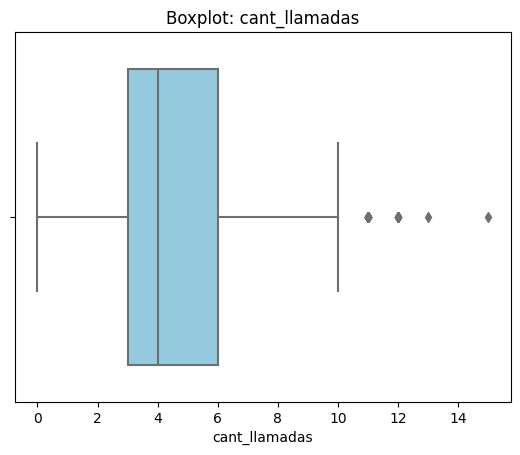

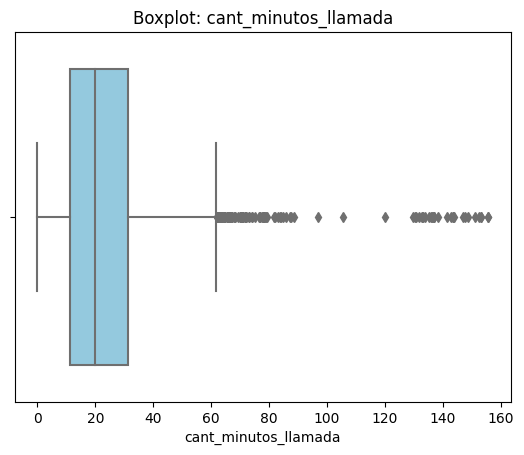

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights: 
- Age: <span style="color:blue">No presenta outliers</span>
- cant_mensajes: <span style="color:blue">Si presenta outliers, solo superiores</span>
- cant_llamadas: <span style="color:blue">Si presenta outliers, solo superiores</span>
- cant_minutos_llamada: <span style="color:blue">Si presenta outliers, solo superiores</span>

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    superior = q3 + 1.5 * iqr
    inferior = q1 - 1.5 * iqr
    print(f'Limite Inferior: {inferior} Limite Superior: {superior}')



Limite Inferior: -12.0 Limite Superior: 108.0
Limite Inferior: -0.5 Limite Superior: 11.5
Limite Inferior: -1.5 Limite Superior: 10.5
Limite Inferior: -19.322500000000005 Limite Superior: 61.8575


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? <span style="color:blue">Para cant_mensajes se mantendrían los outliers, aunque el limite superior es 11.5, es perfectamente normal que un usuario mande 17 mensajes. No corresponde a un error de captura</span>
- cant_llamadas: mantener o no outliers, porqué?<span style="color:blue">Similar al caso anterior. En este caso se esta reflejando un comportamiento normal de un usuario. Un usuario haciendo 15 llamadas es totalmente posible. Por lo tanto se conservarian los outliers</span>
- cant_minutos_llamada: mantener o no outliers, porqué? <span style="color:blue">En este caso, la diferencia entre el limite superior y el max es muy grande. En este caso se podría reemplazar los valores mayores al límite superior por el límite superior (61.8). Esto mitiga el impacto de los extremos sin eliminar los registros</span>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Las visualizaciones están bien planteadas: usaste histogramas con `hue='plan'`, agregaste títulos y escribiste interpretaciones útiles. Sin embargo, el cálculo de límites IQR necesita corregirse, porque la fórmula usada suma `1.5 + iqr` en lugar de multiplicar `1.5 * iqr`. Revisa nuevamente los límites con `Q1 - 1.5 * IQR` y `Q3 + 1.5 * IQR`, y luego actualiza tu decisión sobre conservar, revisar o limitar outliers. Este ajuste es importante porque la conclusión sobre `cant_minutos_llamada` depende directamente de esos límites.

</div>


- Se corrige formula de limites IQR.
- Se ajusta comentario en `cant_minutos_llamada`

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
def clasificar_uso(row):
    c_llamadas = row['cant_llamadas']
    c_mensajes = row['cant_mensajes']

    if c_llamadas < 5 and c_mensajes < 5:
        return 'Bajo uso'
    elif c_llamadas < 10 and c_mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [41]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad

def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [43]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

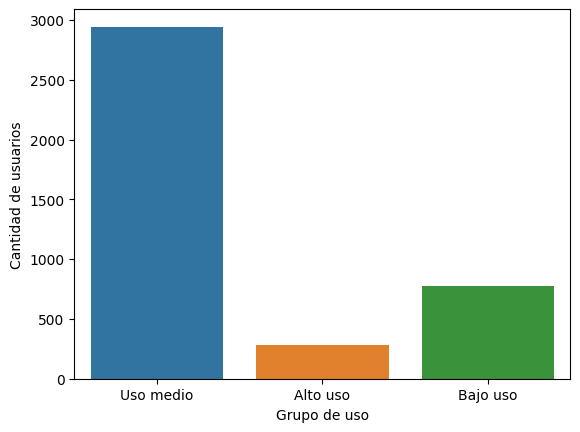

In [44]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

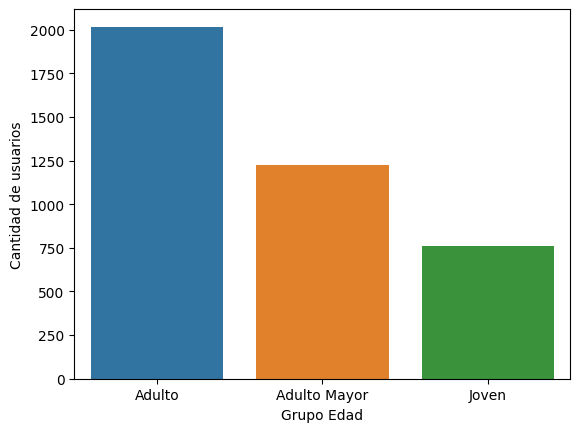

In [45]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.xlabel('Grupo Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo creando las segmentaciones de clientes por nivel de uso y por edad. Las reglas son coherentes con la consigna y las visualizaciones permiten ver rápidamente la distribución de cada grupo. Aunque usaste funciones con `.apply()` en lugar de `np.where`, la lógica está bien implementada y es clara para este nivel del proyecto.

</div>



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante el proceso de exploración y limpieza se identificaron los siguientes problemas:

**age:** 55 registros contenían el valor centinela -999, indicando edades no capturadas. Fueron reemplazados por la mediana.

**city:** 469 registros con valores nulos y 96 registros con `?`. Al estar en el rango 5-30%, se investigó y se marcaron como nulos.

**reg_date:** Se detectaron fechas futuras (año > 2024), marcadas como NaT.

**duration** y **length** en **usage**: nulos estructurales por diseño — duration aplica solo a llamadas y length solo a mensajes de texto, no son datos faltantes reales.

**cant_minutos_llamada:** tiene outliers con valores que casi triplican el límite superior

🔍 **Segmentos por Edad**
- La base de usuarios está dominada por adultos de 30 a 60 años, representando la mitad de la base total.
- Los jóvenes son el segmento más pequeño, lo que podría indicar que los planes actuales no son atractivos para ese grupo.
- Los adultos mayores representan casi un tercio de la base, un segmento que suele tener mayor estabilidad y menor propensión al abandono.


📊 **Segmentos por Nivel de Uso**
- El uso medio domina ampliamente, lo que indica que la mayoría de la base tiene un consumo moderado y predecible.
- El segmento de bajo uso es preocupante: usuarios que apenas consumen el servicio son más susceptibles al abandono, especialmente si están pagando un plan que no aprovechan.
- El segmento de alto uso es pequeño pero valioso: son los usuarios más comprometidos con el servicio y probablemente los más rentables.

➡️ Esto sugiere que ...
La mayoría de los usuarios no lleva el consumo al límite de su plan, lo que podría indicar que los planes están sobredimensionados para el uso real, o que los usuarios desconocen todos los beneficios incluidos. La edad no diferencia el plan contratado (Básico vs Premium).

💡 **Recomendaciones**
- Crear campaña de retención para usuarios de bajo uso: identificar a los usuarios de bajo uso y contactarlos proactivamente antes de que abandonen, ofreciendo incentivos o planes más ajustados a su consumo real.
- Estrategia de upselling para usuarios Básico con alto consumo de mensajes: estos usuarios están pagando excedentes regularmente y son candidatos naturales para migrar a Premium.
- Revisar la propuesta de valor para el segmento joven: se debería evaluar si los planes actuales cubren las necesidades de ese segmento (más datos, más mensajes) o si se necesita un plan específico para ellos.


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

El análisis ejecutivo está bien orientado al negocio: resumes problemas de calidad, describes segmentos y propones recomendaciones accionables. Como mejora, revisa los números reportados para `city`, porque en el proyecto el sentinel principal esperado es `"?"`; conviene separar claramente valores nulos reales de valores inválidos. Además, cuando corrijas el cálculo IQR, actualiza la parte de outliers para que el insight ejecutivo quede alineado con el análisis corregido.

</div>


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/josheshinmxc/telecom-analysis/tree/main`

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a>

El repositorio de GitHub fue compartido y contiene el notebook junto con un README que explica el objetivo, los datasets, las etapas del análisis y la forma de ejecución. Esto cumple con el entregable de publicación y reproducibilidad. 

</div>
